# 02 - Plot detectors.

Here's what finally worked. The (x,y) of the focal plane is weirdly specified, so I do some fiddling to end up with coordinates that are just integers in [0,15)

In [11]:
import lsdb
from lsdb import ConeSearch
from nested_pandas.utils import count_nested
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from lsst.afw import cameraGeom
from lsst.obs.lsst import LsstCam
from collections import defaultdict

lsdb.show_versions()


--------      SYSTEM INFO      --------
python        : 3.12.11
python-bits   : 64
OS            : Linux
OS-release    : 5.14.0-570.58.1.el9_6.x86_64
Version       : #1 SMP PREEMPT_DYNAMIC Fri Oct 31 13:55:05 UTC 2025
machine       : x86_64
processor     : 
byteorder     : little
LC_ALL        : 
LANG          : 
--------   INSTALLED VERSIONS   --------
lsdb          : 0.8.2
hats          : 0.8.2
nested-pandas : 0.6.8
pandas        : 2.3.1
numpy         : 2.4.2
dask          : 2025.7.0
pyarrow       : 17.0.0
fsspec        : 2025.7.0


In [2]:
camera = LsstCam().getCamera()
raw_data = defaultdict(list)
for det in camera:
    if det.getType() == cameraGeom.DetectorType.SCIENCE:
        raw_data["detector_id"].append(det.getId())
   
        focal_plane = det.getCenter(cameraGeom.FOCAL_PLANE)
        raw_data["focal_plane_x"].append(focal_plane.x)
        raw_data["focal_plane_y"].append(focal_plane.y)

In [7]:
rec_array = np.full((15,15), -100)
simplified_x = np.round(np.array((raw_data["focal_plane_x"]))/42).astype(int) + 7
simplified_y = np.round(np.array((raw_data["focal_plane_y"]))/42).astype(int) + 7
for index, (x, y) in enumerate(zip(simplified_x, simplified_y)):
    rec_array[x][y] = index
# rec_array

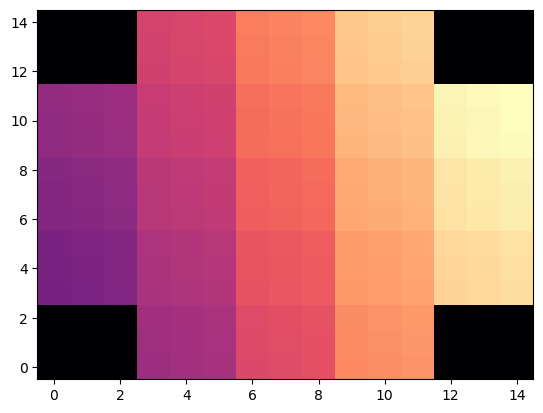

In [8]:
fig, ax = plt.subplots()

x = np.arange(0, 15)
y = np.arange(0, 15)

ax.pcolormesh(x, y, rec_array, cmap='magma')

In [13]:
detector_simplified_xy = pd.DataFrame({"id": raw_data["detector_id"], "x": simplified_x, "y":simplified_y})
detector_simplified_xy.to_csv("detector_simplified_xy.csv", index=False)